# 01 — Pengolahan PDF UU (Step by Step)

Notebook ini menampilkan **seluruh proses pengolahan** file PDF undang-undang dari awal hingga siap diindeks:

| Tahap | Proses | Output |
|---|---|---|
| 1 | Baca PDF dengan `pdfplumber` | Teks mentah per halaman |
| 2 | Buang nomor halaman | Teks tanpa halaman |
| 3 | Buang header/footer berulang | Teks tanpa artefak |
| 4 | Buang preamble sebelum BAB I | Teks isi UU saja |
| 5 | Deteksi posisi BAB | Daftar BAB + judulnya |
| 6 | Potong per Pasal | Daftar chunk |
| 7 | Sub-chunking pasal panjang | Chunk siap indeks |

**Tidak ada prasyarat** — notebook ini langsung membaca PDF dari `data/raw/`.

In [15]:
import sys, re, json
from pathlib import Path
from collections import Counter

import pdfplumber

sys.path.insert(0, str(Path.cwd().parent))
from src.config import load_config, resolve_path

cfg = load_config()
raw_dir = resolve_path(cfg['paths']['raw_dir'])

# Kita pakai UU Ketenagakerjaan sebagai contoh.
# Ganti nama file untuk melihat UU lain.
PDF_PATH = raw_dir / 'UU Ketenagakerjaan.pdf'
print('PDF yang digunakan:', PDF_PATH)
print('File ada:', PDF_PATH.exists())

PDF yang digunakan: C:\legal-hybrid-retrieval\data\raw\UU Ketenagakerjaan.pdf
File ada: True


---
## Tahap 1 — Baca PDF dengan `pdfplumber`

`pdfplumber` membaca PDF halaman per halaman dan mengekstrak teks mentah. Tiap halaman dipisahkan dengan baris kosong ganda.

In [16]:
pages_raw: list[str] = []
with pdfplumber.open(str(PDF_PATH)) as pdf:
    for page in pdf.pages:
        txt = page.extract_text() or ''
        pages_raw.append(txt)

print(f'Jumlah halaman terbaca: {len(pages_raw)}')
print()
print('=== Contoh halaman ke-10 (mentah, sebelum dibersihkan) ===')
print(pages_raw[9][:600])

Jumlah halaman terbaca: 230

=== Contoh halaman ke-10 (mentah, sebelum dibersihkan) ===
luar perusahaan, yang bersifat bebas, terbuka,
mandiri, demokratis, dan bertanggung jawab
guna memperjuangkan, membela serta
melindungi hak dan kepentingan pekerja/buruh
serta meningkatkan kesejahteraan pekerja/buruh
dan keluarganya.
18. Lembaga kerja sama bipartit adalah forum
komunikasi dan konsultasi mengenai hal-hal
yang berkaitan dengan hubungan industrial di
satu perusahaan yang anggotanya terdiri dari
pengusaha dan serikat pekerja/ serikat buruh
yang sudah tercatat instansi yang bertanggung
jawab di bidang ketenagakerjaan atau unsur
pekerja/buruh.
19. Lembaga kerja sama tripartit adalah


---
## Tahap 2 — Buang Nomor Halaman

Baris yang **hanya berisi angka** (mis. `"247"`) adalah nomor halaman dan tidak membawa informasi hukum. Baris ini dibuang.

In [17]:
_PAGE_NUM_RE = re.compile(r'^\d{1,4}$')

raw_text = '\n\n'.join(pages_raw)
all_lines = [ln.strip() for ln in raw_text.splitlines()]

page_nums = [ln for ln in all_lines if _PAGE_NUM_RE.match(ln) and ln]
print(f'Baris nomor halaman ditemukan: {len(page_nums)} baris')
print('Contoh:', page_nums[:10])

Baris nomor halaman ditemukan: 231 baris
Contoh: ['2003', '1', '2', '3', '4', '5', '6', '7', '8', '9']


---
## Tahap 3 — Deteksi dan Buang Header/Footer Berulang

PDF UU sering mencetak nama undang-undang di setiap halaman sebagai header atau footer.
Baris yang muncul **≥ 5 kali** dan panjangnya **≤ 40 karakter** dianggap header/footer dan dibuang.

In [18]:
counts = Counter(
    ln for ln in all_lines
    if 0 < len(ln) <= 40
    and not ln.lower().startswith(('pasal', 'bab', 'ayat'))
)
footers = {ln for ln, c in counts.items() if c >= 5}

print(f'Header/footer terdeteksi ({len(footers)} jenis):')
for f in sorted(footers):
    print(f'  [{counts[f]}x]  "{f}"')

Header/footer terdeteksi (23 jenis):
  [271x]  "Cukup jelas."
  [12x]  "Huruf a"
  [12x]  "Huruf b"
  [8x]  "Huruf c"
  [8x]  "Huruf d"
  [9x]  "Keputusan Menteri."
  [8x]  "Menteri."
  [9x]  "berlaku."
  [6x]  "bersama."
  [8x]  "bersangkutan."
  [6x]  "dan"
  [5x]  "dengan Keputusan Menteri."
  [5x]  "dengan Peraturan Pemerintah."
  [5x]  "dengan peraturan perundang-undangan yang"
  [7x]  "kerja."
  [8x]  "ketenagakerjaan."
  [8x]  "pekerja/buruh."
  [5x]  "pengusaha."
  [8x]  "perjanjian kerja bersama."
  [9x]  "perundang-undangan yang berlaku."
  [5x]  "perusahaan."
  [7x]  "sebagaimana dimaksud dalam ayat (1)"
  [6x]  "upah;"


In [19]:
# Terapkan pembersihan: buang nomor halaman & footer
cleaned_lines = [
    ln for ln in all_lines
    if ln
    and not _PAGE_NUM_RE.match(ln)
    and ln not in footers
]
text_after_clean = '\n'.join(cleaned_lines)

print(f'Baris sebelum pembersihan : {len(all_lines)}')
print(f'Baris setelah pembersihan : {len(cleaned_lines)}')
print(f'Baris yang dibuang        : {len(all_lines) - len(cleaned_lines)}')

Baris sebelum pembersihan : 5558
Baris setelah pembersihan : 4663
Baris yang dibuang        : 895


---
## Tahap 4 — Buang Preamble (Bagian Sebelum BAB I)

Setiap UU diawali bagian pembukaan hukum (`Menimbang`, `Mengingat`, `Menetapkan`, dll.) yang tidak mengandung isi pasal.
Teks dipotong mulai dari **`BAB I`**.

Untuk UU perubahan (mis. UU 35/2014 tentang Perlindungan Anak) yang tidak punya `BAB I`,
fallback ke penanda **`MEMUTUSKAN`**.

In [20]:
_BAB_SATU_RE = re.compile(r'^BAB\s+I\b', re.MULTILINE)
_MEMUTUSKAN_RE = re.compile(r'^MEMUTUSKAN', re.MULTILINE)

m = _BAB_SATU_RE.search(text_after_clean)
fallback_used = False
if m is None:
    m = _MEMUTUSKAN_RE.search(text_after_clean)
    fallback_used = True

if m:
    preamble = text_after_clean[:m.start()]
    text_clean = text_after_clean[m.start():]
    print(f'Penanda yang dipakai : {"MEMUTUSKAN (fallback)" if fallback_used else "BAB I"}')
    print(f'Panjang preamble yang dibuang : {len(preamble)} karakter')
    print(f'Panjang teks isi UU           : {len(text_clean)} karakter')
else:
    text_clean = text_after_clean
    print('Penanda BAB I / MEMUTUSKAN tidak ditemukan. Teks tidak dipotong.')

print()
print('=== 5 baris pertama setelah pemotongan preamble ===')
print('\n'.join(text_clean.splitlines()[:5]))

Penanda yang dipakai : BAB I
Panjang preamble yang dibuang : 2530 karakter
Panjang teks isi UU           : 160006 karakter

=== 5 baris pertama setelah pemotongan preamble ===
BAB I
KETENTUAN UMUM
Pasal 1
Dalam undang undang ini yang dimaksud dengan:
1. Ketenagakerjaan adalah segala hal yang


---
## Tahap 5 — Deteksi Posisi BAB

Sistem mencari semua penanda `BAB X` di awal baris beserta judulnya (baris deskriptif setelah `BAB X`).
Informasi ini dipakai sebagai metadata tiap chunk.

In [21]:
_BAB_RE = re.compile(r'(?m)^BAB\s+([A-Z]+)\b')
_BAB_TITLE_STOP_RE = re.compile(r'^(Pasal|Bagian|Paragraf|BAB)\b', re.IGNORECASE)

def _extract_bab_title(text: str, after: int) -> str:
    lines = []
    for raw in text[after:].splitlines():
        line = raw.strip()
        if not line:
            if lines: break
            continue
        if _BAB_TITLE_STOP_RE.match(line): break
        lines.append(line)
        if len(lines) >= 3: break
    return ' '.join(lines).title()

babs = [
    (m.start(), f'BAB {m.group(1)}', _extract_bab_title(text_clean, m.end()))
    for m in _BAB_RE.finditer(text_clean)
]

print(f'Jumlah BAB ditemukan: {len(babs)}')
print()
print(f'{"Label":<12} {"Judul"}')
print('-' * 55)
for _, label, title in babs:
    print(f'{label:<12} {title}')

Jumlah BAB ditemukan: 18

Label        Judul
-------------------------------------------------------
BAB I        Ketentuan Umum
BAB II       Landasan, Asas, Dan Tujuan
BAB III      Kesempatan Dan Perlakuan Yang Sama
BAB IV       Landasan, Asas, Dan Tujuan
BAB V        Pelatihan Kerja
BAB VI       Penempatan Tenaga Kerja
BAB VII      Perluasan Kesempatan Kerja
BAB VIII     Penggunaan Tenaga Kerja Asing
BAB IX       Hubungan Kerja
BAB X        Perlindungan, Pengupahan, Dan Kesejahteraan
BAB XI       Hubungan Industrial
BAB XII      Pemutusan Hubungan Kerja
BAB XIII     Pembinaan
BAB XIV      Pengawasan
BAB XV       Penyidikan
BAB XVI      Ketentuan Pidana Dan Sanksi Administratif
BAB XVII     Ketentuan Peralihan
BAB XVIII    Ketentuan Penutup


---
## Tahap 6 — Potong Per Pasal

Regex `^Pasal N$` mencari semua **kepala pasal** yang berdiri sendiri di satu baris.
Teks antara dua pasal berurutan menjadi satu chunk.

> Tanpa anchor `\s*$`, rujukan silang seperti `"Pasal 140, pengusaha dilarang:"` di tengah kalimat
> bisa salah terbaca sebagai batas pasal baru — bug ini sempat merusak ~36% chunk.

In [8]:
_PASAL_RE = re.compile(r'(?m)^Pasal\s+(\d+[A-Za-z]*)\s*$')

matches = list(_PASAL_RE.finditer(text_clean))
print(f'Jumlah kepala pasal ditemukan: {len(matches)}')
print()
print('10 pasal pertama yang terdeteksi:')
for m in matches[:10]:
    print(f'  Pasal {m.group(1):>6}  (posisi karakter: {m.start()})')

Jumlah kepala pasal ditemukan: 386

10 pasal pertama yang terdeteksi:
  Pasal      1  (posisi karakter: 21)
  Pasal      2  (posisi karakter: 7237)
  Pasal      3  (posisi karakter: 7358)
  Pasal      4  (posisi karakter: 7503)
  Pasal      5  (posisi karakter: 7948)
  Pasal      6  (posisi karakter: 8053)
  Pasal      7  (posisi karakter: 8189)
  Pasal      8  (posisi karakter: 8637)
  Pasal      9  (posisi karakter: 9346)
  Pasal     10  (posisi karakter: 9529)


In [23]:
# Tampilkan contoh teks mentah satu pasal sebelum normalisasi
idx = 10  # indeks pasal ke-11 (0-based)
m = matches[idx]
end = matches[idx + 1].start() if idx + 1 < len(matches) else len(text_clean)
raw_pasal = text_clean[m.start():end]

print(f'=== Teks mentah Pasal {m.group(1)} (sebelum normalisasi) ===')
print(raw_pasal[:500])

=== Teks mentah Pasal 11 (sebelum normalisasi) ===
Pasal 11
Setiap tenaga kerja berhak untuk memperoleh
dan/atau meningkatkan dan/atau mengembangkan
kompetensi kerja sesuai dengan bakat, minat, dan
kemampuannya melalui pelatihan kerja.



---
## Tahap 6b — Normalisasi Teks (Reflow)

Teks PDF sering ter-wrap di tengah kalimat karena batas kolom halaman.
`_normalize()` menggabungkan semua newline menjadi spasi tunggal agar teks mengalir wajar.

In [24]:
def _normalize(text: str) -> str:
    text = text.replace('\n', ' ')
    return re.sub(r'\s+', ' ', text).strip()

normalized = _normalize(raw_pasal)

print(f'=== Pasal {m.group(1)} setelah normalisasi ===')
print(normalized[:500])

=== Pasal 11 setelah normalisasi ===
Pasal 11 Setiap tenaga kerja berhak untuk memperoleh dan/atau meningkatkan dan/atau mengembangkan kompetensi kerja sesuai dengan bakat, minat, dan kemampuannya melalui pelatihan kerja.


---
## Tahap 7 — Sub-Chunking Pasal Panjang

IndoSBERT memiliki batas panjang input (~256 kata). Pasal yang melebihi batas ini
dipecah menjadi beberapa **sub-chunk** dengan overlap kecil agar konteks tidak putus di batas potongan.

In [25]:
MAX_TOKENS = cfg['chunking']['max_tokens']

def _split_long(text: str, max_tokens: int, overlap: int = 0) -> list[str]:
    words = text.split()
    if len(words) <= max_tokens:
        return [text]
    parts, start = [], 0
    step = max(1, max_tokens - overlap)
    while start < len(words):
        parts.append(' '.join(words[start:start + max_tokens]))
        start += step
    return parts

# Cari pasal terpanjang sebagai contoh
pasal_panjang = max(
    range(len(matches)),
    key=lambda i: len(text_clean[matches[i].start():
                                  (matches[i+1].start() if i+1 < len(matches) else len(text_clean))].split())
)
mp = matches[pasal_panjang]
ep = matches[pasal_panjang + 1].start() if pasal_panjang + 1 < len(matches) else len(text_clean)
body_panjang = _normalize(text_clean[mp.start():ep])
parts = _split_long(body_panjang, MAX_TOKENS)

print(f'Pasal terpanjang : Pasal {mp.group(1)}')
print(f'Jumlah kata      : {len(body_panjang.split())}')
print(f'Batas max_tokens : {MAX_TOKENS}')
print(f'Dipecah menjadi  : {len(parts)} sub-chunk')
print()
for i, p in enumerate(parts):
    print(f'  Sub-chunk {i}: {len(p.split())} kata | "{p[:80]}..."')

Pasal terpanjang : Pasal 193
Jumlah kata      : 1084
Batas max_tokens : 256
Dipecah menjadi  : 5 sub-chunk

  Sub-chunk 0: 256 kata | "Pasal 193 Undang undang ini mulai berlaku pada tanggal diundangkan. Agar setiap ..."
  Sub-chunk 1: 256 kata | "dalam TAP MPR Nomor XVII/MPR/1998 harus diwujudkan. Dalam bidang ketenagakerjaan..."
  Sub-chunk 2: 256 kata | "598 a); Undang-undang Nomor 3 Tahun 1958 tentang Penempatan Tenaga Asing (Lembar..."
  Sub-chunk 3: 256 kata | "era reformasi tahun 1998. Di bidang ketenagakerjaan internasional, penghargaan t..."
  Sub-chunk 4: 60 kata | "dan penyelesaian perselisihan hubungan industrial; Perlindungan pekerja/buruh, t..."


---
## Hasil Akhir — Semua Chunk dalam Satu Proses

Jalankan sel di bawah untuk melihat seluruh chunk yang dihasilkan dari UU ini menggunakan fungsi resmi `chunk_by_pasal()`.

In [26]:
import pandas as pd
from dataclasses import asdict
from src.ingest import extract_text, clean_text
from src.chunk import chunk_by_pasal

# Proses lengkap dalam 3 baris
raw = extract_text(PDF_PATH)
bersih = clean_text(raw)
chunks = chunk_by_pasal(bersih, domain='ketenagakerjaan', max_tokens=MAX_TOKENS)

df = pd.json_normalize([asdict(c) for c in chunks])
df['n_kata'] = df['text'].str.split().str.len()

print(f'Total chunk : {len(df)}')
print(f'Chunk normal (1 pasal = 1 chunk) : {len(df[df["metadata.part"] == 0])}')
print(f'Sub-chunk (pasal dipecah)        : {len(df[df["metadata.part"] > 0])}')
print()
df[['id', 'metadata.bab', 'metadata.pasal', 'metadata.part', 'n_kata']].head(15)

Total chunk : 401
Chunk normal (1 pasal = 1 chunk) : 386
Sub-chunk (pasal dipecah)        : 15



,id,metadata.bab,metadata.pasal,metadata.part,n_kata
0,KETENAGAKERJAAN_PASAL_1,BAB I,1,0,256
1,KETENAGAKERJAAN_PASAL_1_p1,BAB I,1,1,256
2,KETENAGAKERJAAN_PASAL_1_p2,BAB I,1,2,256
3,KETENAGAKERJAAN_PASAL_1_p3,BAB I,1,3,175
4,KETENAGAKERJAAN_PASAL_2,BAB II,2,0,15
5,KETENAGAKERJAAN_PASAL_3,BAB II,3,0,17
6,KETENAGAKERJAAN_PASAL_4,BAB II,4,0,57
7,KETENAGAKERJAAN_PASAL_5,BAB III,5,0,14
8,KETENAGAKERJAAN_PASAL_6,BAB III,6,0,19
9,KETENAGAKERJAAN_PASAL_7,BAB IV,7,0,56


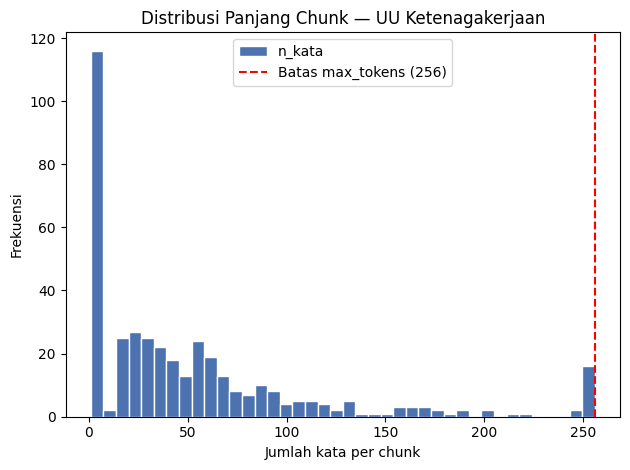

Chunk di bawah batas : 401 (100.0%)
Chunk di atas batas  : 0 (dipecah menjadi sub-chunk)


In [13]:
import matplotlib.pyplot as plt

df['n_kata'].plot(
    kind='hist', bins=40, color='#4C72B0', edgecolor='white',
    title='Distribusi Panjang Chunk — UU Ketenagakerjaan'
)
plt.axvline(MAX_TOKENS, color='red', linestyle='--', label=f'Batas max_tokens ({MAX_TOKENS})')
plt.xlabel('Jumlah kata per chunk')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Chunk di bawah batas : {len(df[df["n_kata"] <= MAX_TOKENS])} ({len(df[df["n_kata"] <= MAX_TOKENS])/len(df)*100:.1f}%)')
print(f'Chunk di atas batas  : {len(df[df["n_kata"] > MAX_TOKENS])} (dipecah menjadi sub-chunk)')

In [27]:
# Lihat isi satu chunk secara lengkap
PASAL = '156'  # Ganti nomor pasal untuk melihat yang lain

hasil = df[df['metadata.pasal'] == PASAL]
if hasil.empty:
    print(f'Pasal {PASAL} tidak ditemukan.')
else:
    for _, row in hasil.iterrows():
        print(f'ID    : {row["id"]}')
        print(f'BAB   : {row["metadata.bab"]}')
        print(f'Part  : {row["metadata.part"]}')
        print(f'Kata  : {row["n_kata"]}')
        print('-' * 60)
        print(row['text'])
        print()

ID    : KETENAGAKERJAAN_PASAL_156
BAB   : BAB XII
Part  : 0
Kata  : 256
------------------------------------------------------------
Pasal 156 1. Dalam hal terjadi pemutusan hubungan kerja, pengusaha diwajibkan membayar uang pesangon dan atau uang penghargaan masa kerja dan uang penggantian hak yang seharusnya diterima. 2. Perhitungan uang pesangon sebagaimana dimaksud dalam ayat (1) paling sedikit sebagai berikut : a. masa kerja kurang dari 1 (satu) tahun, 1 (satu) bulan upah; b. masa kerja 1 (satu) tahun atau lebih tetapi kurang dari 2 (dua) tahun, 2 (dua) bulan c. masa kerja 2 (dua) tahun atau lebih tetapi kurang dari 3 (tiga) tahun, 3 (tiga) bulan d. masa kerja 3 (tiga) tahun atau lebih tetapi kurang dari 4 (empat) tahun, 4 (empat) bulan upah; e. masa kerja 4 (empat) tahun atau lebih tetapi kurang dari 5 (lima) tahun, 5 (lima) bulan f. masa kerja 5 (lima) tahun atau lebih, tetapi kurang dari 6 (enam) tahun, 6 (enam) bulan g. masa kerja 6 (enam) tahun atau lebih tetapi kurang dari 7